# 🧠 Non-Spatial Multi-Class Fraud Detection Pipeline

This notebook demonstrates a **non-spatial behavioral and temporal pipeline** for detecting fraud scenarios. 

### Why this approach?
1. **Excluding Spatial Noise:** Exploratory Data Analysis shows that the average distance between a customer and a terminal is identical for both legitimate (~3.309) and fraudulent (~3.302) transactions. Direct spatial coordinates or Euclidean distances act as noise and can cause overfitting.
2. **Multi-Class Targeting:** Instead of simple binary classification (0 or 1), we train the classifier on the four distinct scenarios (`TX_FRAUD_SCENARIO`): 
   - **Class 0:** Legitimate Baseline
   - **Class 1:** Fixed-Threshold Card Testing Scripts
   - **Class 2:** Stealth Merchant/Terminal Exploits
   - **Class 3:** Account-Draining Identity Theft
3. **Balanced Training:** We configure the model with `class_weight='balanced'` to address the severe class imbalance (99% legit vs. 1% fraud).

### Cell 1: Import Libraries
We import essential libraries for data loading, processing, model building, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Libraries successfully imported!")

Libraries successfully imported!


### Cell 2: Load the Datasets
We load the profiles and synthetic transactions from the `full dataset with brief/` directory.

In [2]:
print("Loading datasets from CSV files...")
customer_profiles = pd.read_csv('full dataset with brief/customer_profiles.csv')
fraud_transactions = pd.read_csv('full dataset with brief/synthetic_fraud_transactions.csv')
terminal_profiles = pd.read_csv('full dataset with brief/terminal_profiles.csv')

print(f"Customer Profiles shape: {customer_profiles.shape}")
print(f"Transactions shape: {fraud_transactions.shape}")
print(f"Terminal Profiles shape: {terminal_profiles.shape}")

Loading datasets from CSV files...
Customer Profiles shape: (5000, 7)
Transactions shape: (1754155, 9)
Terminal Profiles shape: (10000, 3)


### Cell 3: Data Merging (Excluding Spatial Coordinates)
We merge transactions with customer and terminal statistics. To prevent spatial overfitting, we **exclude** all location coordinate columns (`x_customer_id`, `y_customer_id`, `x_terminal_id`, `y_terminal_id`).

In [3]:
print("Merging datasets...")

# Merge customer stats (excluding customer coordinates)
df = fraud_transactions.merge(
    customer_profiles[['CUSTOMER_ID', 'mean_amount', 'std_amount', 'mean_nb_tx_per_day', 'nb_terminals']],
    on='CUSTOMER_ID',
    how='left'
)

# Merge terminal information (excluding terminal coordinates)
df = df.merge(
    terminal_profiles[['TERMINAL_ID']],
    on='TERMINAL_ID',
    how='left'
)

print(f"Columns in merged DataFrame:\n{df.columns.tolist()}")

Merging datasets...
Columns in merged DataFrame:
['TRANSACTION_ID', 'TX_DATETIME', 'CUSTOMER_ID', 'TERMINAL_ID', 'TX_AMOUNT', 'TX_TIME_SECONDS', 'TX_TIME_DAYS', 'TX_FRAUD', 'TX_FRAUD_SCENARIO', 'mean_amount', 'std_amount', 'mean_nb_tx_per_day', 'nb_terminals']


### Cell 4: Non-Spatial Feature Engineering
We engineer dedicated features targeting our temporal and behavioral signatures:
1. **Temporal Module:** Extract hour, day of the week, total seconds since midnight, and day number.
2. **Behavioral Deviation Module:** Calculate ratio (`TX_AMOUNT / mean_amount`) and Z-score relative to customer history.
3. **Terminal Frequency/Velocity Module:** Calculate terminal transaction frequency mapping.

In [4]:
print("Engineering non-spatial features...")

# Convert TX_DATETIME to pandas datetime format
df['TX_DATETIME'] = pd.to_datetime(df['TX_DATETIME'])

# 1. Temporal Features
df['tx_hour'] = df['TX_DATETIME'].dt.hour
df['tx_dow'] = df['TX_DATETIME'].dt.dayofweek
df['tx_seconds'] = (df['TX_DATETIME'].dt.hour * 3600 + 
                     df['TX_DATETIME'].dt.minute * 60 + 
                     df['TX_DATETIME'].dt.second)
df['tx_daynum'] = (df['TX_DATETIME'] - df['TX_DATETIME'].min()).dt.days

# 2. Behavioral Deviation Features
df['amount_ratio'] = df['TX_AMOUNT'] / df['mean_amount']
df['amount_z_score'] = (df['TX_AMOUNT'] - df['mean_amount']) / (df['std_amount'] + 1e-5)

# 3. Terminal Frequency Feature
term_counts = df['TERMINAL_ID'].value_counts()
df['term_count'] = df['TERMINAL_ID'].map(term_counts).fillna(0)

print("Feature engineering complete. Sample computed values:")
df[['TX_AMOUNT', 'tx_hour', 'amount_ratio', 'amount_z_score', 'term_count']].head()

Engineering non-spatial features...
Feature engineering complete. Sample computed values:


,TX_AMOUNT,tx_hour,amount_ratio,amount_z_score,term_count
0,57.16,0,1.385504,0.771008,146
1,81.51,0,0.953390,-0.093219,161
2,146.00,0,1.820134,1.640267,235
3,64.49,0,1.157662,0.315324,238
4,50.99,0,0.915840,-0.168320,137


### Cell 5: Train-Test Selection & Imbalance Sampling
We define the engineered feature columns and select `TX_FRAUD_SCENARIO` as our target variable. 
To make execution fast and interactive for you, we train on a stratified 10% sample of the 1.75 million transaction records.

In [5]:
features = [
    'TX_AMOUNT', 'tx_hour', 'tx_dow', 'tx_seconds', 'tx_daynum',
    'mean_amount', 'std_amount', 'mean_nb_tx_per_day', 'nb_terminals',
    'amount_ratio', 'amount_z_score', 'term_count'
]
target = 'TX_FRAUD_SCENARIO'

# Stratified sampling of 10% of records
df_sample = df.sample(frac=0.1, random_state=42)
df_sample = df_sample.dropna(subset=[target])

X = df_sample[features]
y = df_sample[target].astype(int)

print(f"Feature columns: {features}")
print(f"Target column: {target}")
print("\nClass counts in the training sample (0 = Legit, 1-3 = Fraud Scenarios):")
print(y.value_counts().sort_index())

Feature columns: ['TX_AMOUNT', 'tx_hour', 'tx_dow', 'tx_seconds', 'tx_daynum', 'mean_amount', 'std_amount', 'mean_nb_tx_per_day', 'nb_terminals', 'amount_ratio', 'amount_z_score', 'term_count']
Target column: TX_FRAUD_SCENARIO

Class counts in the training sample (0 = Legit, 1-3 = Fraud Scenarios):
TX_FRAUD_SCENARIO
0    173972
1        79
2       882
3       483
Name: count, dtype: int64


### Cell 6: Train/Test Stratified Split
We perform an 80/20 train-test split, ensuring that the target class proportions (the rare fraud scenarios) are identical in both sets.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training instances: {X_train.shape[0]}")
print(f"Testing instances: {X_test.shape[0]}")

Training instances: 140332
Testing instances: 35084


### Cell 7: Model Pipeline Configuration
We create a scikit-learn preprocessing pipeline using imputation and standard scaling, followed by a multi-class `RandomForestClassifier` configured with `class_weight='balanced'` to prevent majority-class bias.

In [7]:
# Preprocessing pipeline
preprocessing = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Random Forest Classifier with balanced weights
clf = Pipeline([
    ('pre', preprocessing),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ))
])

### Cell 8: Train the Classifier
We train the Random Forest on the engineered training dataset.

In [8]:
print("Training Multi-Class Classifier on non-spatial behavioral data...")
clf.fit(X_train, y_train)
print("Training completed!")

Training Multi-Class Classifier on non-spatial behavioral data...
Training completed!


### Cell 9: Model Evaluation
We predict the target scenarios on the holdout test set, printing the precision, recall, and F1-score details per scenario. We also plot the resulting Confusion Matrix.

Classification Report per Class/Scenario:
                                  precision    recall  f1-score   support

   Class 0 (Legitimate Baseline)     0.9947    0.9349    0.9639     34795
Class 1 (Fixed-Threshold Script)     0.8824    0.9375    0.9091        16
      Class 2 (Stealth Merchant)     0.0079    0.1023    0.0147       176
  Class 3 (Whale Identity-Theft)     0.9419    0.8351    0.8852        97

                        accuracy                         0.9305     35084
                       macro avg     0.7067    0.7024    0.6932     35084
                    weighted avg     0.9896    0.9305    0.9589     35084



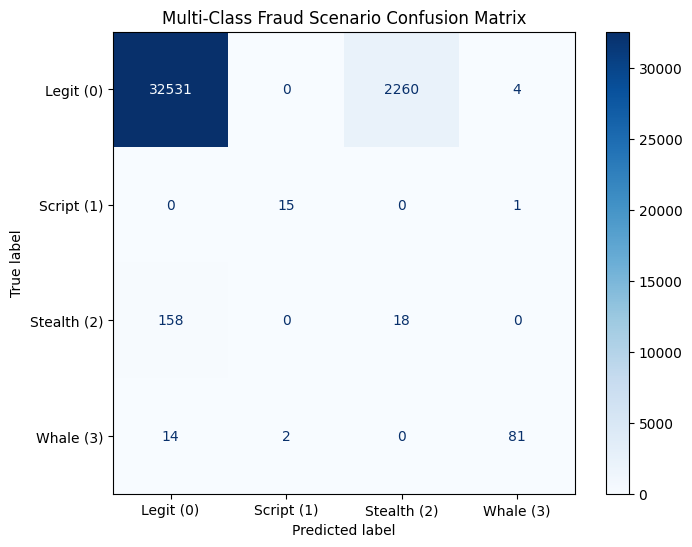

In [9]:
y_pred = clf.predict(X_test)

print("Classification Report per Class/Scenario:")
print(classification_report(y_test, y_pred, target_names=[
    'Class 0 (Legitimate Baseline)',
    'Class 1 (Fixed-Threshold Script)',
    'Class 2 (Stealth Merchant)',
    'Class 3 (Whale Identity-Theft)'
], digits=4))

# Display the Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[
    'Legit (0)', 'Script (1)', 'Stealth (2)', 'Whale (3)'
])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Multi-Class Fraud Scenario Confusion Matrix")
plt.show()

### Cell 10: Feature Importance Inspection
Finally, we extract the random forest's feature importance weights to verify which engineered behavioral and temporal features were most instrumental in classifying fraud.

/tmp/ipykernel_5297/683276305.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


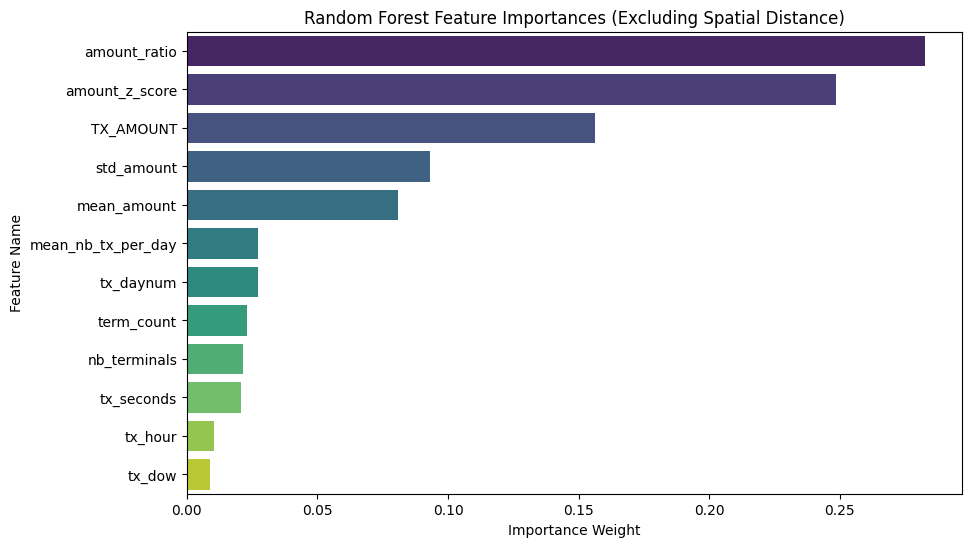

,Feature,Importance
9,amount_ratio,0.282622
10,amount_z_score,0.248655
0,TX_AMOUNT,0.156432
6,std_amount,0.092910
5,mean_amount,0.080702
7,mean_nb_tx_per_day,0.027333
4,tx_daynum,0.027275
11,term_count,0.022899
8,nb_terminals,0.021450
3,tx_seconds,0.020617


In [10]:
rf_model = clf.named_steps['rf']
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("Random Forest Feature Importances (Excluding Spatial Distance)")
plt.xlabel("Importance Weight")
plt.ylabel("Feature Name")
plt.show()

importance_df